<a href="https://colab.research.google.com/github/thunderingluck/MultiBench/blob/main/examples/affect/demo_per_layer_gates_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Per-Layer Sigmoid Gates for Multimodal Fusion

**Extension of DynMM (Xue & Marculescu, CVPR 2023)**

Instead of DynMM's single input-level gate that selects between pre-trained branches, we place an **independent sigmoid gate at each transformer layer for each modality**.  
This allows the network to learn patterns like:

> *"use text from layer 1, add audio at layer 3, skip video entirely"*

-- all on a **per-sample** basis, end-to-end from scratch.

### Gate mechanism

$$g_{m,l} = \sigma\!\left(W \cdot \text{mean\_pool}(h_{m,l})\right) \in (0,1)$$

Applied as a gated residual so gradients always flow:

$$h_{m,l+1} = g_{m,l}\; h_{m,l}^{\text{new}} + (1 - g_{m,l})\; h_{m,l}$$

$g \approx 1$ → modality fully updates at this layer &nbsp;&nbsp; $g \approx 0$ → modality passes through unchanged

### Dataset
CMU-MOSEI sentiment regression (visual=35, audio=74, text=300-d GloVe, seq_len≤50)

## 1 · Setup
# ── Checkpoint directory: persistent across Colab sessions ──────────────────



In [7]:
!pip install torch==2.5.1 torchvision==0.20.1 --index-url https://download.pytorch.org/whl/cu124

Looking in indexes: https://download.pytorch.org/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 908.2/908.2 MB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 80.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 106.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 64.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 130.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 12.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 44.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 12.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/1

In [8]:
import sys, os

# ── Colab: clone the repo if it is not already present ──────────────────────
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    if not os.path.isdir('/content/MultiBench'):
        !git clone https://github.com/pliang279/MultiBench /content/MultiBench
    REPO_ROOT = '/content/MultiBench'
else:
    # Running locally: notebook lives in examples/affect/ — go up two levels
    REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..', '..'))

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

print('Repository root:', REPO_ROOT)

Repository root: /content/MultiBench


In [9]:
if IN_COLAB:
    CHECKPOINT_DIR = '/content/drive/MyDrive/plg_checkpoints'
else:
    CHECKPOINT_DIR = os.path.join(REPO_ROOT, 'log', 'mosei')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print('Checkpoint dir:', CHECKPOINT_DIR)

Checkpoint dir: /content/drive/MyDrive/plg_checkpoints


In [10]:
# Install / verify dependencies
try:
    import torch
    print(f'PyTorch {torch.__version__} | CUDA available: {torch.cuda.is_available()}')
except ImportError:
    !pip install -q torch torchvision

try:
    import scipy
except ImportError:
    !pip install -q scipy

try:
    import sklearn
except ImportError:
    !pip install -q scikit-learn

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import pearsonr

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

PyTorch 2.5.1+cu124 | CUDA available: True


## 2 · Data

The CMU-MOSEI pickle file can be found at:  
**Google Drive folder** → `1A_hTmifi824gypelGobgl2M-5Rw9VWHv`

Run the cell that matches your environment.

In [11]:
# ── Option A: Google Colab — mount Drive and point to the file ───────────────
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    # After mounting, locate mosei_senti_data.pkl inside the shared folder.
    # The path below assumes the folder is in 'My Drive'; adjust if needed.
    DRIVE_FOLDER = '/content/drive/MyDrive/mosei'          # change if in a sub-folder
    DATA_PATH = os.path.join(DRIVE_FOLDER, 'mosei_senti_data.pkl')

    # If the file is directly in the shared folder (not copied to My Drive),
    # you can also use gdown to download it once:
    if not os.path.exists(DATA_PATH):
        print('File not found in My Drive — downloading with gdown …')
        !pip install -q gdown
        import gdown
        # Download the entire shared folder into /content/mosei_data/
        gdown.download_folder(
            id='1A_hTmifi824gypelGobgl2M-5Rw9VWHv',
            output='/content/mosei_data',
            quiet=False,
        )
        DATA_PATH = '/content/mosei_data/mosei_senti_data.pkl'

else:
    # ── Option B: local run — set path relative to repo root ────────────────
    DATA_PATH = os.path.join(REPO_ROOT, 'data', 'mosei_senti_data.pkl')

print('Data path:', DATA_PATH)
assert os.path.exists(DATA_PATH), (
    f'File not found: {DATA_PATH}\n'
    'Please copy mosei_senti_data.pkl to the path above.'
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data path: /content/drive/MyDrive/mosei/mosei_senti_data.pkl


In [12]:
# Patch out the torchtext import since we don't use it (robust_test=False)
import importlib, types

# Create a dummy torchtext module so the import doesn't crash
fake_torchtext = types.ModuleType('torchtext')
fake_torchtext.vocab = types.ModuleType('torchtext.vocab')
sys.modules['torchtext'] = fake_torchtext
sys.modules['torchtext.vocab'] = fake_torchtext.vocab

In [13]:
import sys

# Assume IN_COLAB is True from an earlier cell execution
# It's safer to always ensure compatibility in Colab, especially after
# # previous attempts resulted in an OSError due to ABI mismatch.
# if IN_COLAB:
#     !pip install -q torch==2.1.0 torchtext==0.16.0 --index-url https://download.pytorch.org/whl/cu121

from datasets.affect.get_data import get_dataloader

BATCH_SIZE  = 32
MAX_SEQ_LEN = 50

# max_pad=True → _process_2 collate → (vision [B,T,35], audio [B,T,74], text [B,T,300], labels [B,1])
# is_packed=False in the training loop  (no variable-length packing needed)
traindata, validdata, testdata = get_dataloader(
    DATA_PATH,
    batch_size=BATCH_SIZE,
    max_pad=True,
    max_seq_len=MAX_SEQ_LEN,
    robust_test=False,
    data_type='mosei',
    num_workers=0,   # set >0 on machines with multiple CPU cores
)

# Quick sanity check
sample = next(iter(traindata))
v, a, t, y = sample
print(f'vision  : {tuple(v.shape)}   (B, T, 35)')
print(f'audio   : {tuple(a.shape)}   (B, T, 74)')
print(f'text    : {tuple(t.shape)}   (B, T, 300)')
print(f'labels  : {tuple(y.shape)}')
print(f'train batches: {len(traindata)}  |  valid: {len(validdata)}  |  test: {len(testdata)}')


vision  : (32, 50, 35)   (B, T, 35)
audio   : (32, 50, 74)   (B, T, 74)
text    : (32, 50, 300)   (B, T, 300)
labels  : (32, 1)
train batches: 509  |  valid: 59  |  test: 146


## 3 · Model

`PLGModel` wraps `PerLayerGatedFusion` (the encoder) with a linear regression head.  
It implements the `moe_model` interface used by `Supervised_Learning.train()`, so no changes to the existing training infrastructure are needed.

In [14]:
from fusions.per_layer_gated import PLGModel

# Hyper-parameters
D_MODEL  = 64   # hidden dimension (shared across all modalities)
N_HEADS  = 4    # transformer attention heads (must divide D_MODEL)
N_LAYERS = 4    # depth = number of gate levels per modality
DROPOUT  = 0.1
REG      = 0.01  # weight for gate sparsity regularisation

model = PLGModel(
    in_dims=[35, 74, 300],   # CMU-MOSEI: visual, audio, text
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    dropout=DROPOUT,
)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'PLGModel  d_model={D_MODEL}  n_layers={N_LAYERS}  n_heads={N_HEADS}')
print(f'Trainable parameters: {n_params:,}')
print()
print(model)

PLGModel  d_model=64  n_layers=4  n_heads=4
Trainable parameters: 627,149

PLGModel(
  (encoder): PerLayerGatedFusion(
    (projections): ModuleList(
      (0): Conv1d(35, 64, kernel_size=(1,), stride=(1,))
      (1): Conv1d(74, 64, kernel_size=(1,), stride=(1,))
      (2): Conv1d(300, 64, kernel_size=(1,), stride=(1,))
    )
    (tf_layers): ModuleList(
      (0-2): 3 x ModuleList(
        (0-3): 4 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
          )
          (linear1): Linear(in_features=64, out_features=256, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=256, out_features=64, bias=True)
          (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): 

In [15]:
# ── Quick shape test (no GPU required) ─────────────────────────────────────
with torch.no_grad():
    dummy = [torch.randn(4, MAX_SEQ_LEN, d) for d in [35, 74, 300]]
    pred, reg = model(dummy)
    print(f'pred shape : {tuple(pred.shape)}   (B, 1)')
    print(f'reg_loss   : {reg.item():.4f}   (mean gate value — should be ~0.5 at init)')

    gates = model.encoder.forward(dummy)[1]
    print(f'gates shape: {tuple(gates.shape)}   (B, n_modalities, n_layers)')

pred shape : (4, 1)   (B, 1)
reg_loss   : 0.5071   (mean gate value — should be ~0.5 at init)
gates shape: (4, 3, 4)   (B, n_modalities, n_layers)


## 4 · Training

We reuse the existing `Supervised_Learning.train()` loop via the `moe_model=` hook.  
The total loss is:

$$\mathcal{L} = \underbrace{\text{MAE}(\hat{y}, y)}_{\text{task}} + \lambda \cdot \underbrace{\text{mean}(g_{m,l})}_{\text{gate sparsity}}$$

The sparsity term encourages the model to use fewer transformer layers per modality.

In [18]:
import sys
sys.stdout.write(str(type(model)) + '\n')
sys.stdout.write(str([n for n, _ in model.named_children()]) + '\n')

<class 'fusions.per_layer_gated.PLGModel'>
['encoder', 'head']


20

In [19]:
import sys, torch
sys.stdout.write(f'PyTorch: {torch.__version__}\n')

PyTorch: 2.5.1+cu124


21

In [20]:
batch = next(iter(traindata))
sys.stdout.write(f'Type: {type(batch)}\n')
sys.stdout.write(f'Length: {len(batch)}\n')
for i, item in enumerate(batch):
    if hasattr(item, 'shape'):
        sys.stdout.write(f'  [{i}] Tensor shape={item.shape}, dtype={item.dtype}\n')
    elif isinstance(item, list):
        sys.stdout.write(f'  [{i}] List len={len(item)}, first type={type(item[0])}\n')
    else:
        sys.stdout.write(f'  [{i}] {type(item)}\n')

Type: <class 'tuple'>
Length: 4
  [0] Tensor shape=torch.Size([32, 50, 35]), dtype=torch.float32
  [1] Tensor shape=torch.Size([32, 50, 74]), dtype=torch.float32
  [2] Tensor shape=torch.Size([32, 50, 300]), dtype=torch.float32
  [3] Tensor shape=torch.Size([32, 1]), dtype=torch.float32


In [21]:
sys.stdout.write(str(inspect.signature(model.forward)) + '\n')

(inputs)


9

In [24]:
import torch
import os

# Training Hyper-parameters
LR     = 1e-3    # Learning rate
WD     = 1e-4    # Weight decay (L2 penalty)
EPOCHS = 20      # Number of training epochs

# Device configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Model checkpoint path
SAVE = os.path.join(CHECKPOINT_DIR, 'plg_mosei.pt')

print(f'Training will use: {DEVICE}')
print(f'Model will be saved to: {SAVE}')

Training will use: cuda
Model will be saved to: /content/drive/MyDrive/plg_checkpoints/plg_mosei.pt


In [26]:
import sys

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
criterion = torch.nn.L1Loss()
best_val = float('inf')

model.to(DEVICE)

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    for batch in traindata:
        *modalities, targets = batch
        modalities = [m.to(DEVICE) for m in modalities]
        targets = targets.to(DEVICE)

        optimizer.zero_grad()
        # Unpack the model output into prediction and regularization loss
        prediction, reg_loss = model(modalities)

        # Calculate the task loss (MAE) and add the scaled regularization loss
        task_loss = criterion(prediction, targets)
        loss = task_loss + REG * reg_loss

        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in validdata:
            *modalities, targets = batch
            modalities = [m.to(DEVICE) for m in modalities]
            targets = targets.to(DEVICE)
            # Unpack the model output for validation
            prediction, _ = model(modalities) # We don't need reg_loss for validation metric
            val_loss += criterion(prediction, targets).item()

    avg_train = train_loss / len(traindata)
    avg_val = val_loss / len(validdata)
    sys.stdout.write(f'Epoch {epoch+1}/{EPOCHS} | Train: {avg_train:.4f} | Val: {avg_val:.4f}\n')

    if avg_val < best_val:
        best_val = avg_val
        torch.save(model.state_dict(), SAVE)

sys.stdout.write(f'\nTraining complete. Best val loss: {best_val:.4f}, saved to {SAVE}\n')


Epoch 1/20 | Train: 0.7607 | Val: 0.6427
Epoch 2/20 | Train: 0.6666 | Val: 0.6495
Epoch 3/20 | Train: 0.6477 | Val: 0.6120
Epoch 4/20 | Train: 0.6325 | Val: 0.6203
Epoch 5/20 | Train: 0.6260 | Val: 0.6329
Epoch 6/20 | Train: 0.6182 | Val: 0.6031
Epoch 7/20 | Train: 0.6153 | Val: 0.6174
Epoch 8/20 | Train: 0.6062 | Val: 0.6282
Epoch 9/20 | Train: 0.6016 | Val: 0.6198
Epoch 10/20 | Train: 0.6008 | Val: 0.6215
Epoch 11/20 | Train: 0.5959 | Val: 0.6030
Epoch 12/20 | Train: 0.5918 | Val: 0.6027
Epoch 13/20 | Train: 0.5884 | Val: 0.6104
Epoch 14/20 | Train: 0.5891 | Val: 0.5936
Epoch 15/20 | Train: 0.5825 | Val: 0.6001
Epoch 16/20 | Train: 0.5762 | Val: 0.6024
Epoch 17/20 | Train: 0.5759 | Val: 0.6239
Epoch 18/20 | Train: 0.5677 | Val: 0.6111
Epoch 19/20 | Train: 0.5650 | Val: 0.6113
Epoch 20/20 | Train: 0.5654 | Val: 0.6093

Training complete. Best val loss: 0.5936, saved to /content/drive/MyDrive/plg_checkpoints/plg_mosei.pt


104

In [29]:
log_lines = [
    "Epoch 1/20 | Train: 0.7607 | Val: 0.6427",
    "Epoch 2/20 | Train: 0.6666 | Val: 0.6495",
    "Epoch 3/20 | Train: 0.6477 | Val: 0.6120",
    "Epoch 4/20 | Train: 0.6325 | Val: 0.6203",
    "Epoch 5/20 | Train: 0.6260 | Val: 0.6329",
    "Epoch 6/20 | Train: 0.6182 | Val: 0.6031",
    "Epoch 7/20 | Train: 0.6153 | Val: 0.6174",
    "Epoch 8/20 | Train: 0.6062 | Val: 0.6282",
    "Epoch 9/20 | Train: 0.6016 | Val: 0.6198",
    "Epoch 10/20 | Train: 0.6008 | Val: 0.6215",
    "Epoch 11/20 | Train: 0.5959 | Val: 0.6030",
    "Epoch 12/20 | Train: 0.5918 | Val: 0.6027",
    "Epoch 13/20 | Train: 0.5884 | Val: 0.6104",
    "Epoch 14/20 | Train: 0.5891 | Val: 0.5936",
    "Epoch 15/20 | Train: 0.5825 | Val: 0.6001",
    "Epoch 16/20 | Train: 0.5762 | Val: 0.6024",
    "Epoch 17/20 | Train: 0.5759 | Val: 0.6239",
    "Epoch 18/20 | Train: 0.5677 | Val: 0.6111",
    "Epoch 19/20 | Train: 0.5650 | Val: 0.6113",
    "Epoch 20/20 | Train: 0.5654 | Val: 0.6093",
    "",
    "Training complete. Best val loss: 0.5936, saved to /content/drive/MyDrive/plg_checkpoints/plg_mosei.pt"
]

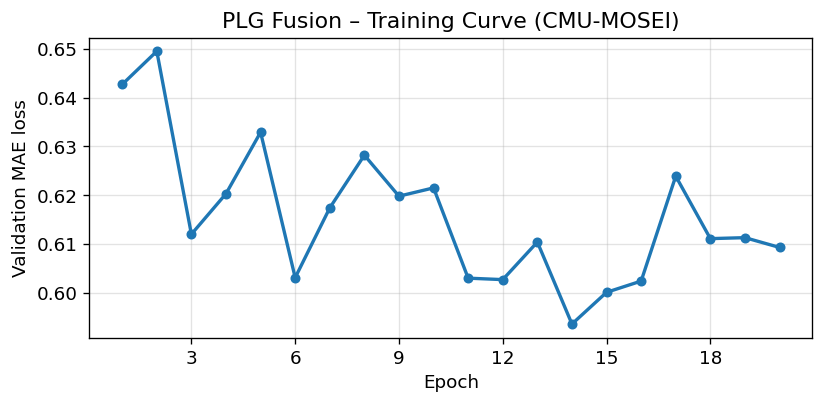

In [37]:
# Parse and plot validation losses from training output
import re

epoch_nums, valid_losses = [], []
for line in log_lines:
    # Updated regex to match 'Val: [value]' format
    m = re.search(r'Epoch\s+(\d+).*Val:\s+([0-9.]+)', line)
    if m:
        epoch_nums.append(int(m.group(1)))
        valid_losses.append(float(m.group(2)))

if valid_losses:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.plot(epoch_nums, valid_losses, marker='o', linewidth=2, markersize=5)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Validation MAE loss')
    ax.set_title('PLG Fusion – Training Curve (CMU-MOSEI)')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(True, alpha=0.35)
    plt.tight_layout()
    plt.show()
else:
    print('No epoch logs captured — check that training printed loss lines.')

## 5 · Evaluate

In [40]:
best_model = PLGModel(
    in_dims=[35, 74, 300],
    d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS, dropout=DROPOUT,
)
best_model.load_state_dict(torch.load(SAVE, weights_only=True))
best_model.to(DEVICE)
best_model.eval()

PLGModel(
  (encoder): PerLayerGatedFusion(
    (projections): ModuleList(
      (0): Conv1d(35, 64, kernel_size=(1,), stride=(1,))
      (1): Conv1d(74, 64, kernel_size=(1,), stride=(1,))
      (2): Conv1d(300, 64, kernel_size=(1,), stride=(1,))
    )
    (tf_layers): ModuleList(
      (0-2): 3 x ModuleList(
        (0-3): 4 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
          )
          (linear1): Linear(in_features=64, out_features=256, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=256, out_features=64, bias=True)
          (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (gate_nets): Modu

In [42]:
from training_structures.Supervised_Learning import single_test


def evaluate_mae_corr(model, dataloader, device):
    """Compute MAE and Pearson correlation on a dataloader."""
    all_preds, all_labels = [], []
    model.eval()
    with torch.no_grad():
        for batch in dataloader:
            v, a, t, y = batch
            inputs = [v.float().to(device), a.float().to(device), t.float().to(device)]
            pred, _ = model(inputs)
            all_preds.append(pred.squeeze(-1).cpu())
            all_labels.append(y.squeeze(-1).cpu())
    preds  = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()
    mae  = float(np.abs(preds - labels).mean())
    corr, _ = pearsonr(preds, labels)
    acc  = float(np.mean((preds >= 0) == (labels >= 0)))
    return {'MAE': mae, 'Corr': corr, 'Acc (pos/neg)': acc}

val_results  = evaluate_mae_corr(best_model, validdata, DEVICE)
test_results = evaluate_mae_corr(best_model, testdata,  DEVICE)

print('┌─────────────────┬──────────┬──────────┬──────────────┐')
print('│ Split           │   MAE    │   Corr   │ Acc (pos/neg)│')
print('├─────────────────┼──────────┼──────────┼──────────────┤')
print(f"│ Validation      │  {val_results['MAE']:.4f}  │  {val_results['Corr']:.4f}  │    {val_results['Acc (pos/neg)']:.4f}    │")
print(f"│ Test            │  {test_results['MAE']:.4f}  │  {test_results['Corr']:.4f}  │    {test_results['Acc (pos/neg)']:.4f}    │")
print('└─────────────────┴──────────┴──────────┴──────────────┘')

┌─────────────────┬──────────┬──────────┬──────────────┐
│ Split           │   MAE    │   Corr   │ Acc (pos/neg)│
├─────────────────┼──────────┼──────────┼──────────────┤
│ Validation      │  0.5967  │  0.6384  │    0.7592    │
│ Test            │  0.6164  │  0.6576  │    0.7726    │
└─────────────────┴──────────┴──────────┴──────────────┘


## 6 · Visualise Gates

The gate heatmap below shows the **mean sigmoid gate value** across the test set for each **(modality, layer)** pair.

- **Warm colour (g → 1)**: the modality actively transforms its representation at this layer.  
- **Cool colour (g → 0)**: the modality passes through unchanged — effectively *skipped* at this depth.

This reveals the learned **fusion depth** per modality.

In [43]:
# Collect gate values from the full test set
best_model.reset_weight()          # clears accumulation buffer, enables tracking
best_model.eval()
with torch.no_grad():
    for batch in testdata:
        v, a, t, _ = batch
        inputs = [v.float().to(DEVICE), a.float().to(DEVICE), t.float().to(DEVICE)]
        best_model(inputs)         # gate values are accumulated inside the model
best_model._tracking = False

mean_gates = best_model.get_mean_gates()  # [n_modalities, n_layers]
print('Mean gate values [modality × layer]:')
print(mean_gates.numpy().round(3))

Mean gate values [modality × layer]:
[[0.213 0.203 0.258 0.187]
 [0.016 0.04  0.804 0.125]
 [0.384 0.168 0.113 0.173]]


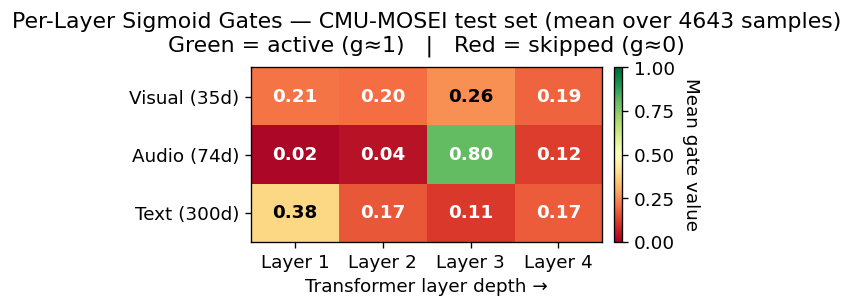

Heatmap saved to /content/drive/MyDrive/plg_checkpoints/plg_gate_heatmap.png


In [45]:
MODALITY_NAMES = ['Visual (35d)', 'Audio (74d)', 'Text (300d)']
n_mod, n_lay = mean_gates.shape

fig, ax = plt.subplots(figsize=(max(5, n_lay * 1.2), max(2.5, n_mod * 0.9)))

im = ax.imshow(mean_gates.numpy(), vmin=0.0, vmax=1.0,
               cmap='RdYlGn', aspect='auto')

# Annotate each cell with the numeric value
for m in range(n_mod):
    for l in range(n_lay):
        val = mean_gates[m, l].item()
        colour = 'black' if 0.25 < val < 0.75 else 'white'
        ax.text(l, m, f'{val:.2f}', ha='center', va='center',
                fontsize=11, color=colour, fontweight='bold')

ax.set_xticks(range(n_lay))
ax.set_xticklabels([f'Layer {l+1}' for l in range(n_lay)])
ax.set_yticks(range(n_mod))
ax.set_yticklabels(MODALITY_NAMES[:n_mod])
ax.set_xlabel('Transformer layer depth →')
ax.set_title(
    f'Per-Layer Sigmoid Gates — CMU-MOSEI test set (mean over {len(testdata.dataset)} samples)\n'
    'Green = active (g≈1)   |   Red = skipped (g≈0)',
    pad=10,
)
cb = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.03)
cb.set_label('Mean gate value', rotation=270, labelpad=15)
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'plg_gate_heatmap.png'), bbox_inches='tight')
plt.show()
print("Heatmap saved to", os.path.join(CHECKPOINT_DIR, 'plg_gate_heatmap.png'))

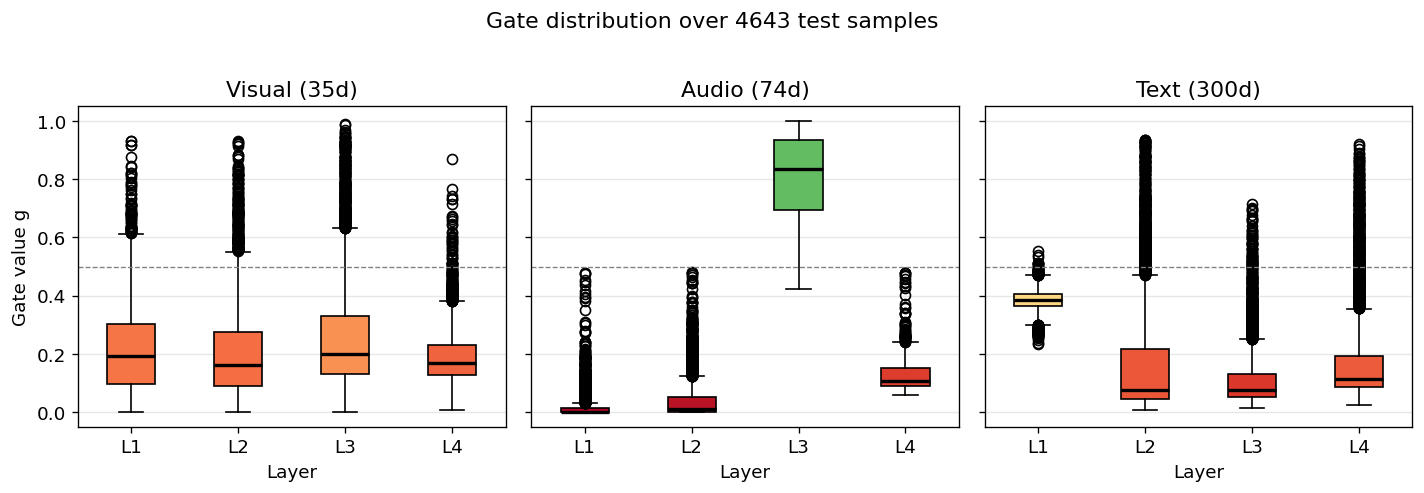

Box-plot saved to /content/drive/MyDrive/plg_checkpoints/plg_gate_boxplots.png


In [47]:
# ── Optional: per-sample gate distribution (box-plot) ──────────────────────
# Shows how much gate values vary across samples for each (modality, layer).

# Re-collect raw gate tensors
best_model.reset_weight()
best_model.eval()
with torch.no_grad():
    for batch in testdata:
        v, a, t, _ = batch
        inputs = [v.float().to(DEVICE), a.float().to(DEVICE), t.float().to(DEVICE)]
        best_model(inputs)
best_model._tracking = False

all_gates = torch.cat(best_model._gate_accum, dim=0)  # [N, M, L]
N = all_gates.shape[0]

fig, axes = plt.subplots(1, n_mod, figsize=(4 * n_mod, 4), sharey=True)
for m, (ax, name) in enumerate(zip(axes, MODALITY_NAMES[:n_mod])):
    data = [all_gates[:, m, l].numpy() for l in range(n_lay)]
    bp = ax.boxplot(data, patch_artist=True, medianprops={'color': 'black', 'lw': 2})
    cmap = plt.cm.RdYlGn
    for patch, l in zip(bp['boxes'], range(n_lay)):
        patch.set_facecolor(cmap(mean_gates[m, l].item()))
    ax.set_xticklabels([f'L{l+1}' for l in range(n_lay)])
    ax.set_xlabel('Layer')
    ax.set_title(name)
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8)
    ax.grid(True, axis='y', alpha=0.3)

axes[0].set_ylabel('Gate value g')
fig.suptitle(f'Gate distribution over {N} test samples', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'plg_gate_boxplots.png'), bbox_inches='tight')
plt.show()
print("Box-plot saved to", os.path.join(CHECKPOINT_DIR, 'plg_gate_boxplots.png'))

## 7 · Regularisation Sweep (Optional)

Higher `λ` encourages sparser (lower) gate values.  
Run this cell to compare gate sparsity vs. MAE across a range of `λ` values.

In [ ]:
REG_SWEEP = [0.0, 0.001, 0.01, 0.1]   # λ values to try
SWEEP_EPOCHS = 5                        # quick sweep — increase for full results

sweep_results = []

for lossw in REG_SWEEP:
    print(f'\n── λ = {lossw} ────────────────────────────────────────────────')
    sweep_model = PLGModel(
        in_dims=[35, 74, 300],
        d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS, dropout=DROPOUT,
    )
    save_path = os.path.join(CHECKPOINT_DIR, f'plg_sweep_{lossw}.pt')
    sl_train(
        encoders=None, fusion=None, head=None,
        train_dataloader=traindata,
        valid_dataloader=validdata,
        total_epochs=SWEEP_EPOCHS,
        moe_model=sweep_model,
        additional_loss=True,
        lossw=lossw,
        task='regression',
        optimtype=torch.optim.Adam,
        lr=LR, weight_decay=WD,
        objective=torch.nn.L1Loss(),
        save=save_path,
        early_stop=False,
        is_packed=False,
        track_complexity=False,
    )
    m = torch.load(save_path).to(DEVICE)
    m.reset_weight()
    m.eval()
    with torch.no_grad():
        for batch in testdata:
            v, a, t, _ = batch
            m([v.float().to(DEVICE), a.float().to(DEVICE), t.float().to(DEVICE)])
    m._tracking = False
    gates_mean = m.get_mean_gates().mean().item()
    res = evaluate_mae_corr(m, testdata, DEVICE)
    res['lossw'] = lossw
    res['mean_gate'] = gates_mean
    sweep_results.append(res)
    print(f'  MAE={res["MAE"]:.4f}  Corr={res["Corr"]:.4f}  mean_gate={gates_mean:.4f}')

# Plot
lws      = [r['lossw']    for r in sweep_results]
maes     = [r['MAE']      for r in sweep_results]
mg       = [r['mean_gate'] for r in sweep_results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
ax1.plot(range(len(lws)), maes,  marker='s', color='steelblue')
ax1.set_xticks(range(len(lws))); ax1.set_xticklabels([str(l) for l in lws])
ax1.set_xlabel('λ (reg weight)'); ax1.set_ylabel('Test MAE'); ax1.set_title('MAE vs λ'); ax1.grid(alpha=0.3)
ax2.plot(range(len(lws)), mg, marker='D', color='darkorange')
ax2.set_xticks(range(len(lws))); ax2.set_xticklabels([str(l) for l in lws])
ax2.set_xlabel('λ (reg weight)'); ax2.set_ylabel('Mean gate value'); ax2.set_title('Gate sparsity vs λ'); ax2.grid(alpha=0.3)
plt.suptitle('Regularisation sweep — sparsity / accuracy trade-off')
plt.tight_layout()
plt.show()

---
## Summary

| Component | Where defined |
|---|---|
| `PerLayerGatedFusion` | `fusions/per_layer_gated.py` |
| `PLGModel` (moe_model wrapper) | `fusions/per_layer_gated.py` |
| Training script (CLI) | `examples/affect/affect_plg.py` |
| Data loader (unchanged) | `datasets/affect/get_data.py` |
| Training loop (unchanged) | `training_structures/Supervised_Learning.py` |

**No existing files were modified.** The new code plugs into the framework via the `moe_model=` hook already present in `Supervised_Learning.train()`.

### Differences from DynMM

| | DynMM | Per-Layer Gates (this work) |
|---|---|---|
| Gate granularity | 1 gate per sample (branch selection) | 1 gate per modality × layer × sample |
| Pre-training required | Yes (unimodal branches first) | No (end-to-end) |
| Interpretability | Which branch was used | Which modality was active at which depth |
| Regularisation | Penalise expensive branch weight | Penalise non-zero gate means |